#Telecom Customer Churn Analysis
## Machine Learning Project
* **Name:** CHANASYA G
* **Tools Used:** PYTHON, SQL, SCIKIT-LEARN, SHAP
* **Dataset:** IBM Telecom customer churn dataset

###Objective
Predict whether a telecom customer is likely yo churn and provide business recommendations to improve customer retention.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import shap

## 2. Load Dataset

In [2]:
df=pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Understand the Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.shape

(7043, 21)

In [43]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'ChurnProbability',
       'CustomerSegment'],
      dtype='object')

## 4. Data Cleaning

In [7]:
df.isnull().sum()
df.drop_duplicates(inplace=True)

In [44]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for column in df.columns:
  if df[column].dtype=="object":
    df[column]=le.fit_transform(df[column])

## 5. Exploratory Data Analytics (EDA)

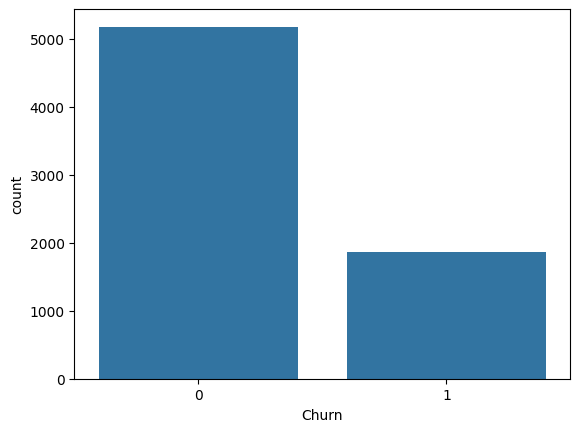

In [45]:
sns.countplot(x="Churn", data=df)
plt.show()

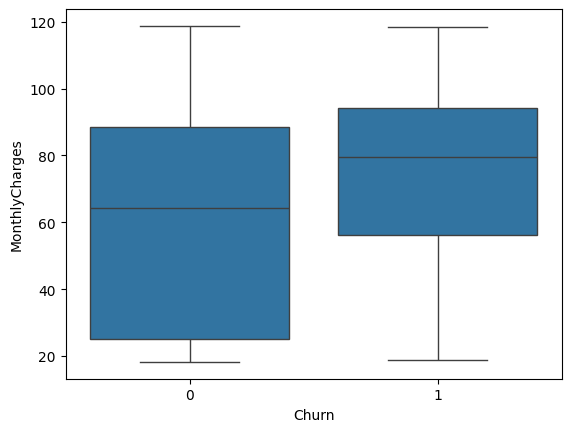

In [46]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

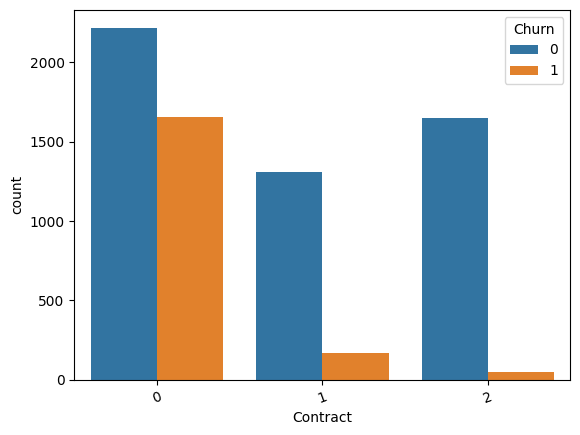

In [47]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.show()

## 6. SQL Analysis

In [13]:
import sqlite3

In [14]:
conn=sqlite3.connect('telecom.db')

In [15]:
df.to_sql("customers", conn, if_exists="replace", index=False)

7043

In [16]:
query="""
SELECT * FROM customers
LIMIT 5;
"""
result=pd.read_sql_query(query, conn)
result

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
query= """
SELECT Churn,
COUNT(*) AS Total
FROM customers
GROUP BY Churn;
"""
pd.read_sql_query(query, conn)

,Churn,Total
0,No,5174
1,Yes,1869


In [18]:
query="""
SELECT AVG(MonthlyCharges) AS Average_Bill
FROM customers
"""
pd.read_sql_query(query, conn)

,Average_Bill
0,64.761692


In [25]:
 query="""
SELECT Contract,
COUNT(*) AS Churned_Customers
FROM customers
WHERE Churn='Yes'
GROUP BY Contract;
"""
pd.read_sql_query(query, conn)

,Contract,Churned_Customers
0,Month-to-month,1655
1,One year,166
2,Two year,48


## 7. Build Machine Learning Model

In [20]:
df=df.drop("customerID", axis=1)

In [22]:
X=df.drop("Churn", axis=1)
y=df["Churn"]

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [28]:
prediction=model.predict(X_test)

## 8. Model Evaluation

In [30]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test, prediction)
print(accuracy)

0.8168914123491838


In [31]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, prediction)
print(cm)

[[938  98]
 [160 213]]


In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



## 9. SHAP Explainability

In [33]:
import shap

In [34]:
explainer=shap.Explainer(model, X_train)

In [35]:
shap_values=explainer(X_test)

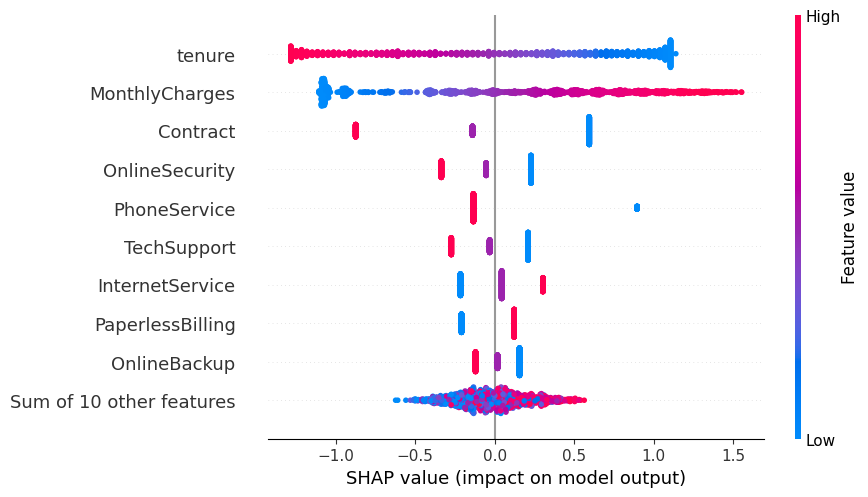

In [36]:
shap.plots.beeswarm(shap_values)

## 10. Customer Segmentation

In [37]:
probability=model.predict_proba(X)[:,1]

In [38]:
df["ChurnProbability"]=probability

In [39]:
def segment(prob):
  if prob>=0.70:
    return "At Risk"
  elif prob>=0.30:
    return "Dormant"
  else:
    return "Loyal"
df["CustomerSegment"]=df["ChurnProbability"].apply(segment)

In [40]:
df["CustomerSegment"].value_counts()

,count
CustomerSegment,
Loyal,4358
Dormant,2250
At Risk,435


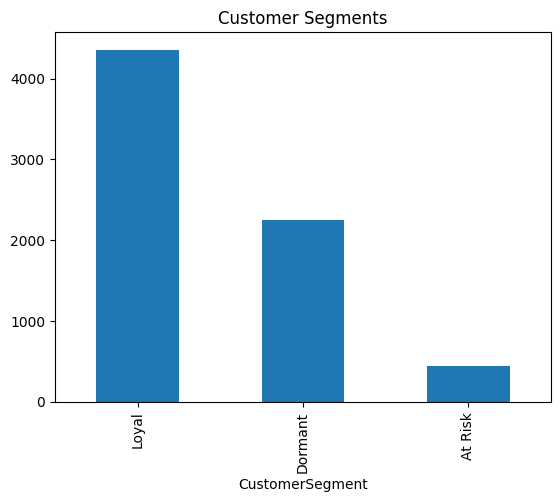

In [41]:
import matplotlib.pyplot as plt
df["CustomerSegment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.show()

In [42]:
df.to_csv("Customer_Churn_Final.csv", index=False)

## 11. Business Recommendations

Based on the analysis and machine learning model, the following recommendations are suggested:

- Encourage customers with month-to-month contracts to switch to yearly plans.
- Reward loyal customers with exclusive offers.
- Provide personalized discounts to customers identified as "At Risk."
- Monitor customers with high monthly charges and offer better value plans.
- Improve customer support to reduce churn caused by service dissatisfaction.

##Conclusion

This project successfully predicted customer churn using a Logistic Regression model. SQL analysis, exploratory data analysis, SHAP explainability, and customer segmentation provided valuable insights into customer behavior. The recommendations can help telecom companies improve customer retention and reduce churn.